In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("Bank Customer Churn Prediction.csv")
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print(df.shape)
print(df.columns)
df.info()
df.describe()

(10000, 12)
Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), st

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [6]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [7]:
df.drop(['RowNumber','CustomerId','Surname'], axis=1, errors='ignore', inplace=True)

In [9]:
df['churn'].value_counts()
df['churn'].value_counts(normalize=True) * 100

churn
0    79.63
1    20.37
Name: proportion, dtype: float64

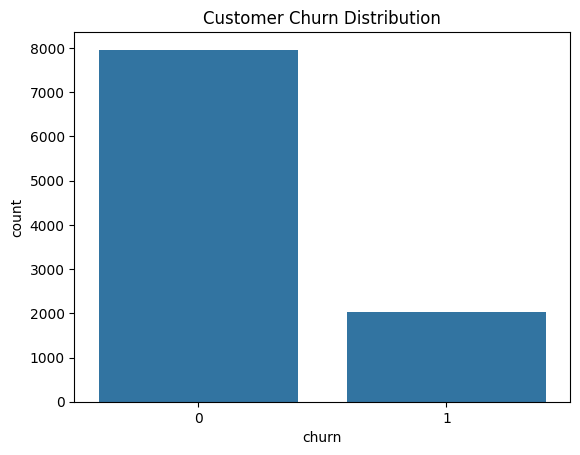

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

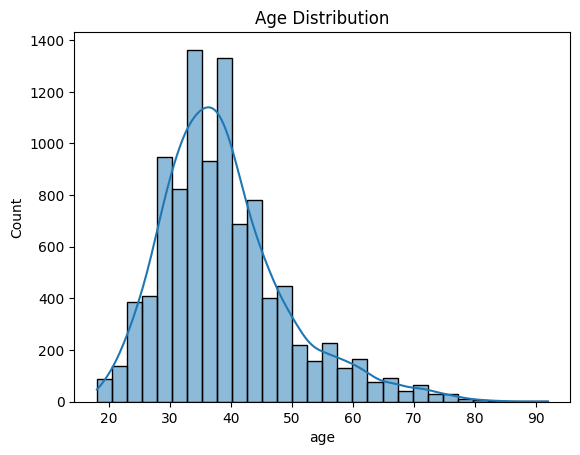

In [11]:
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

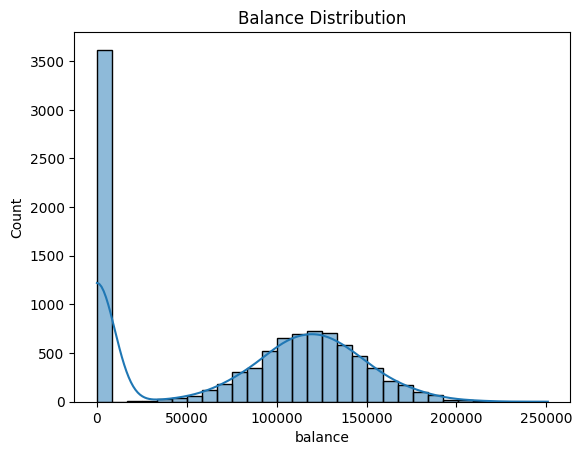

In [12]:
sns.histplot(df['balance'], bins=30, kde=True)
plt.title("Balance Distribution")
plt.show()

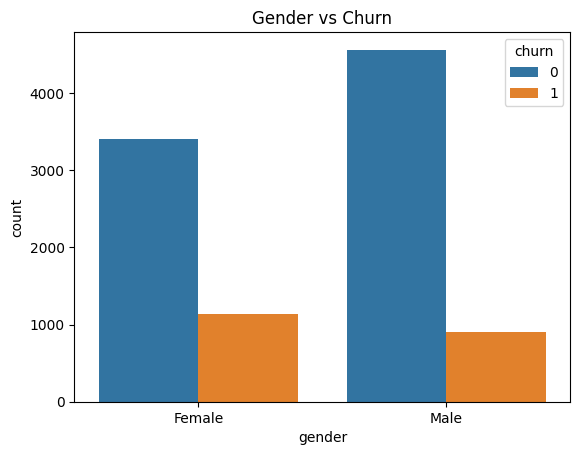

In [13]:
sns.countplot(x='gender', hue='churn', data=df)
plt.title("Gender vs Churn")
plt.show()

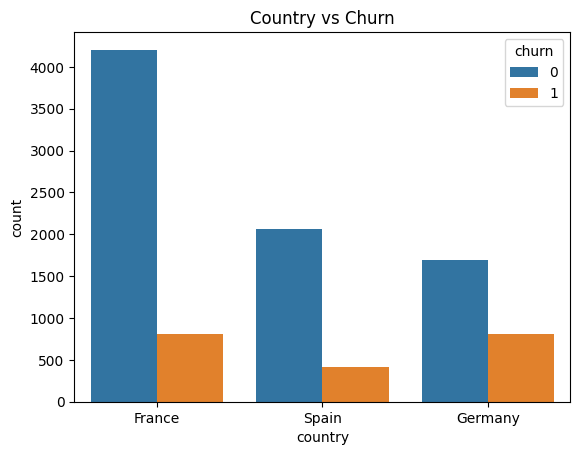

In [14]:
sns.countplot(x='country', hue='churn', data=df)
plt.title("Country vs Churn")
plt.show()

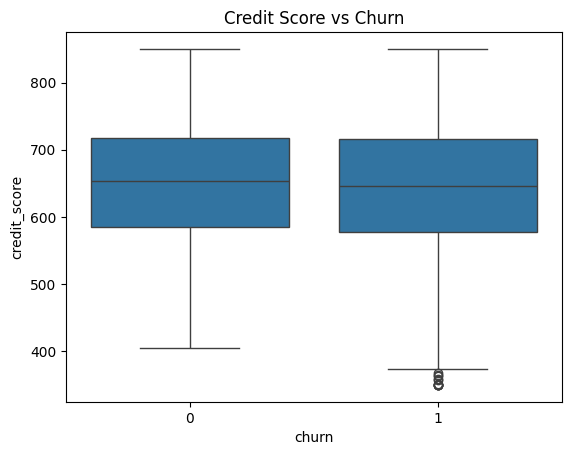

In [15]:
sns.boxplot(x='churn', y='credit_score', data=df)
plt.title("Credit Score vs Churn")
plt.show()

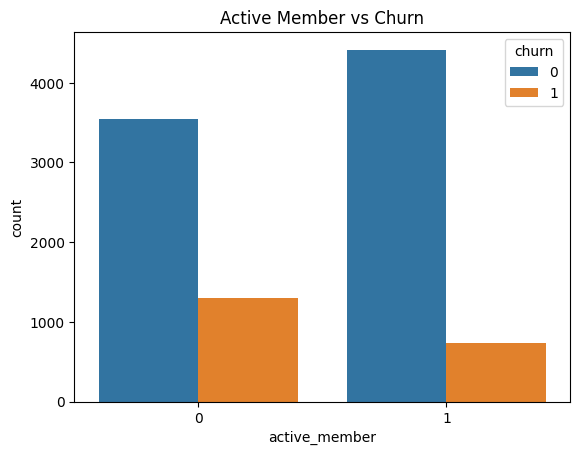

In [16]:
sns.countplot(x='active_member', hue='churn', data=df)
plt.title("Active Member vs Churn")
plt.show()

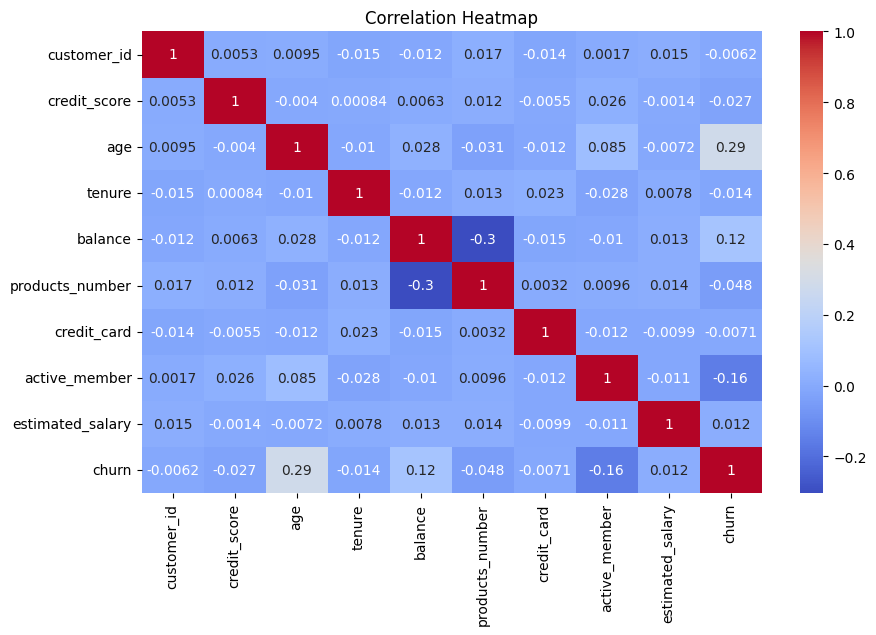

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [18]:
print("Key Insights:")
print("1. Customers with low balance are more likely to churn.")
print("2. Age has strong impact on churn behavior.")
print("3. Customers from some countries churn more.")
print("4. Inactive members are more likely to leave.")
print("5. Credit score affects churn probability.")

Key Insights:
1. Customers with low balance are more likely to churn.
2. Age has strong impact on churn behavior.
3. Customers from some countries churn more.
4. Inactive members are more likely to leave.
5. Credit score affects churn probability.


In [19]:
df.to_csv("Cleaned_Bank_Customer_Churn.csv", index=False)